In [50]:
import pandas as pd

# 换成你的csv路径
df = pd.read_csv(
    "WanChaidistrict/closest_8_central_points_4features.csv",
    low_memory=False
)
# df["motorcycle portion"] = pd.to_numeric(
#     df["motorcycle portion"],
#     errors='coerce'
# )

# 只保留数值列
df_num = df.select_dtypes(include=['number'])

# ===================== 剔除20%异常值（上下各10%） =====================
df_clean = df_num.copy()
for col in df_clean.columns:
    # 计算 10% 和 90% 分位数
    lower = df_clean[col].quantile(0.1)
    upper = df_clean[col].quantile(0.9)
    
    # 只保留中间 80% 的数据
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
# ======================================================================

# 用清洗后的数据计算统计量
stats = pd.DataFrame({
    "Mean": df_clean.mean(),
    "Std": df_clean.std(),
    "Min": df_clean.min(),
    "Max": df_clean.max()
}).round(3)

# 输出可以直接复制进 Excel
print("Variables\tMean\tStd\tMin\tMax")
for idx, row in stats.iterrows():
    print(f"{idx}\t{row['Mean']}\t{row['Std']}\t{row['Min']}\t{row['Max']}")

Variables	Mean	Std	Min	Max
road	nan	nan	nan	nan
sidewalk	nan	nan	nan	nan
building	nan	nan	nan	nan
wall	nan	nan	nan	nan
fence	nan	nan	nan	nan
pole	nan	nan	nan	nan
traffic light	nan	nan	nan	nan
traffic sign	nan	nan	nan	nan
vegetation	nan	nan	nan	nan
terrain	nan	nan	nan	nan
sky	nan	nan	nan	nan
person	nan	nan	nan	nan
rider	nan	nan	nan	nan
car portion	nan	nan	nan	nan
truck portion	nan	nan	nan	nan
bus portion	nan	nan	nan	nan
train portion	nan	nan	nan	nan
motorcycle portion	nan	nan	nan	nan
bicycle portion	nan	nan	nan	nan
is_inlier	nan	nan	nan	nan
pca1	nan	nan	nan	nan
pca2	nan	nan	nan	nan
dist_to_centroid	nan	nan	nan	nan


In [51]:
import pandas as pd
from sklearn.ensemble import IsolationForest

# 换成你的csv路径
df = pd.read_csv(
    "WanChaidistrict/closest_8_central_points_4features.csv",
    low_memory=False
)

# 仅提取全部数值型特征
df_num = df.select_dtypes(include=['number'])
feature_cols = df_num.columns.tolist()
X = df_num.values

# IsolationForest 剔除全局10%离群样本
iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X)
# 1 = 正常样本, -1 = 异常样本
df_num["is_inlier"] = iso.predict(X)

# 保留干净样本
df_clean = df_num[df_num["is_inlier"] == 1].copy()
# 删除标记列，仅保留特征用于统计
df_clean = df_clean.drop("is_inlier", axis=1)

# 清洗前后样本数量对比
print(f"原始样本量: {len(df_num)}")
print(f"剔除10%异常后干净样本量: {len(df_clean)}")

# 计算清洗后特征统计量
stats = pd.DataFrame({
    "Mean": df_clean.mean(),
    "Std": df_clean.std(),
    "Min": df_clean.min(),
    "Max": df_clean.max()
}).round(3)

# 制表输出，可直接粘贴Excel
print("\nVariables\tMean\tStd\tMin\tMax")
for idx, row in stats.iterrows():
    print(f"{idx}\t{row['Mean']}\t{row['Std']}\t{row['Min']}\t{row['Max']}")

原始样本量: 8
剔除10%异常后干净样本量: 7

Variables	Mean	Std	Min	Max
road	29.887	1.289	28.18	31.88
sidewalk	0.283	0.441	0.0	1.24
building	14.984	1.285	13.94	17.56
wall	3.654	2.818	0.0	8.39
fence	2.65	1.956	0.18	5.34
pole	0.143	0.314	0.0	0.85
traffic light	0.0	0.0	0.0	0.0
traffic sign	0.084	0.115	0.0	0.29
vegetation	32.4	2.436	29.52	34.98
terrain	1.154	1.07	0.0	2.5
sky	13.917	1.225	11.88	15.14
person	0.221	0.21	0.0	0.55
rider	0.0	0.0	0.0	0.0
car portion	0.619	1.024	0.0	2.61
truck portion	0.0	0.0	0.0	0.0
bus portion	0.0	0.0	0.0	0.0
train portion	0.0	0.0	0.0	0.0
motorcycle portion	0.0	0.0	0.0	0.0
bicycle portion	0.0	0.0	0.0	0.0
pca1	0.358	2.353	-2.559	3.149
pca2	-0.182	1.393	-2.067	1.602
dist_to_centroid	3.051	0.494	2.333	3.673


In [52]:
import pandas as pd

# 换成你的csv路径
df = pd.read_csv(
    "WanChaidistrict/closest_8_central_points_4features.csv",
    low_memory=False
)

# 只保留数值列
df_num = df.select_dtypes(include=['number'])

# 计算统计量，保留 3 位小数
stats = pd.DataFrame({
    "Mean": df_num.mean(),
    "Std": df_num.std(),
    "Min": df_num.min(),
    "Max": df_num.max()
}).round(3)

# 输出可以直接复制进 Excel 的格式（制表符分隔）
print("Variables\tMean\tStd\tMin\tMax")
for idx, row in stats.iterrows():
    print(f"{idx}\t{row['Mean']}\t{row['Std']}\t{row['Min']}\t{row['Max']}")

Variables	Mean	Std	Min	Max
road	29.754	1.251	28.18	31.88
sidewalk	0.53	0.809	0.0	2.26
building	14.66	1.502	12.39	17.56
wall	3.294	2.801	0.0	8.39
fence	2.82	1.874	0.18	5.34
pole	0.129	0.294	0.0	0.85
traffic light	0.0	0.0	0.0	0.0
traffic sign	0.082	0.106	0.0	0.29
vegetation	32.645	2.36	29.52	34.98
terrain	1.151	0.991	0.0	2.5
sky	13.885	1.138	11.88	15.14
person	0.41	0.568	0.0	1.73
rider	0.0	0.0	0.0	0.0
car portion	0.555	0.965	0.0	2.61
truck portion	0.081	0.23	0.0	0.65
bus portion	0.002	0.007	0.0	0.02
train portion	0.0	0.0	0.0	0.0
motorcycle portion	0.0	0.0	0.0	0.0
bicycle portion	0.0	0.0	0.0	0.0
is_inlier	1.0	0.0	1.0	1.0
pca1	0.719	2.405	-2.559	3.243
pca2	-0.364	1.388	-2.067	1.602
dist_to_centroid	3.152	0.538	2.333	3.855


Yau Tsim Mong loaded, valid samples: 15365
Sham Shui Po loaded, valid samples: 12218
Wan Chai loaded, valid samples: 12654
Central & Western loaded, valid samples: 6641
Southern loaded, valid samples: 7615

===== KDE Distribution Difference Metrics (Baseline: Yau Tsim Mong) =====
       Feature      Reference             Target  KS_Distance  JS_Divergence  \
0     building  Yau Tsim Mong       Sham Shui Po        0.044          0.015   
1     building  Yau Tsim Mong           Wan Chai        0.264          0.203   
2     building  Yau Tsim Mong  Central & Western        0.195          0.148   
3     building  Yau Tsim Mong           Southern        0.326          0.237   
4          sky  Yau Tsim Mong       Sham Shui Po        0.059          0.060   
5          sky  Yau Tsim Mong           Wan Chai        0.250          0.172   
6          sky  Yau Tsim Mong  Central & Western        0.339          0.406   
7          sky  Yau Tsim Mong           Southern        0.210          0.246   

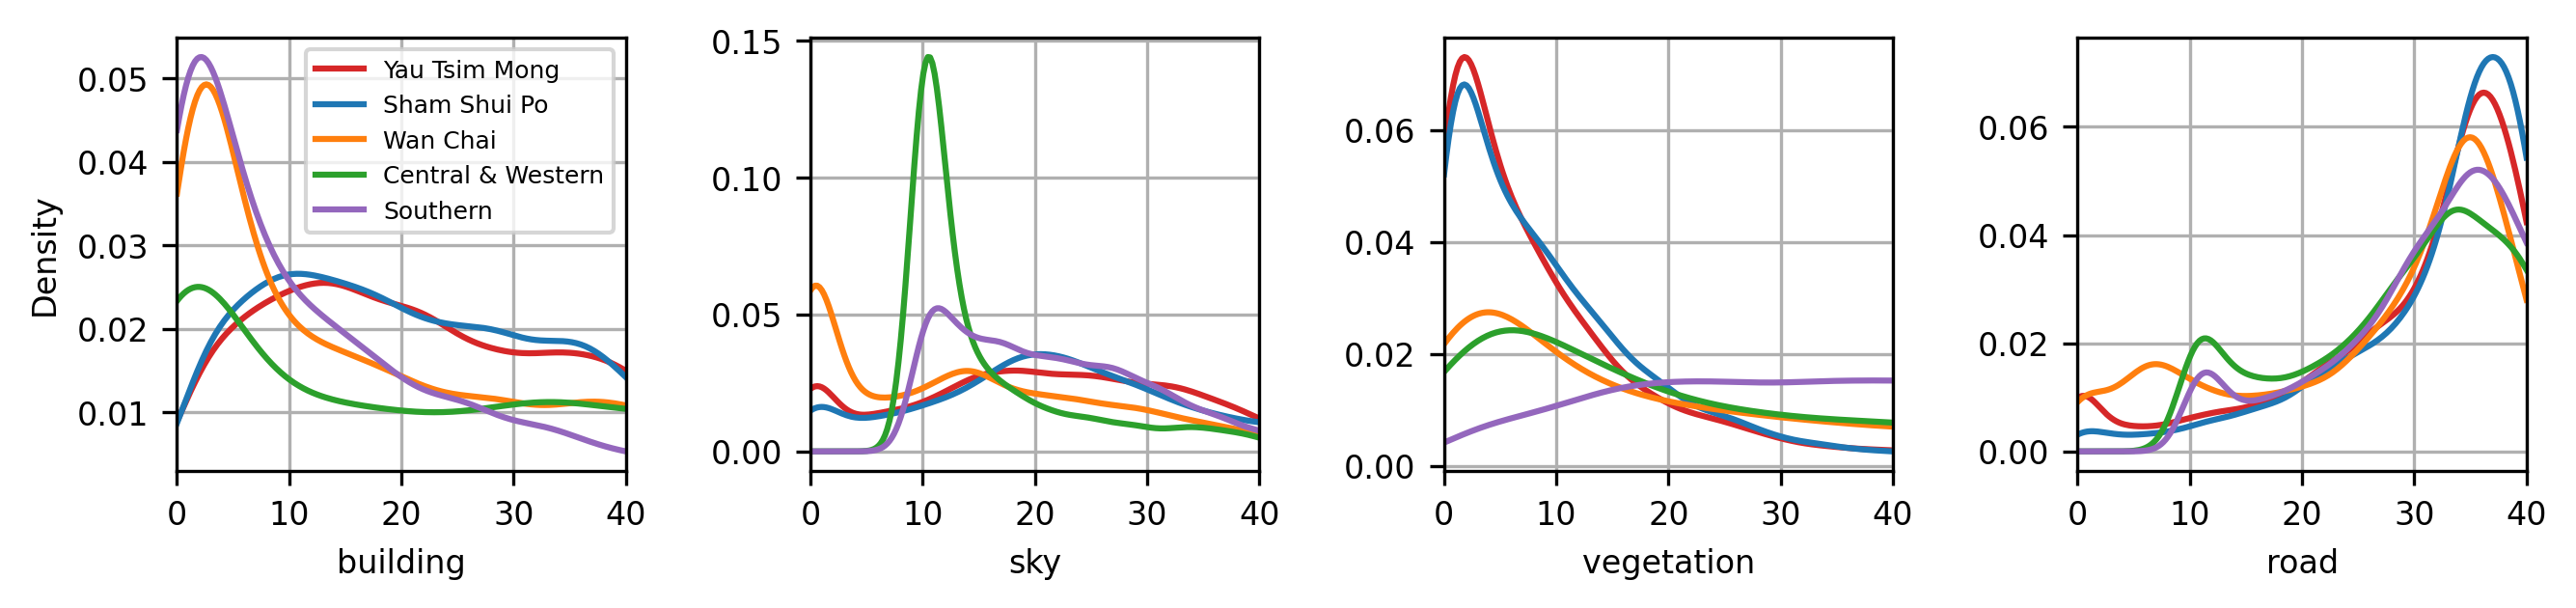

In [81]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, ks_2samp
from scipy.spatial.distance import jensenshannon

# ===================== 配置区：替换为你的5个CSV路径与标签 =====================
file_configs = [
    {
        "path": "YauTsimMongdistrict/segmentation_proportions_香港油尖旺区街景_SVD自己下载的.csv",
        "label": "Yau Tsim Mong",
        "color": "#d62728"
    },
    {
        "path": "ShamShuiPodistrict/segmentation_proportions_香港深水埗街景.csv",
        "label": "Sham Shui Po",
        "color": "#1f77b4"
    },
    {
        "path": "WanChaidistrict/segmentation_proportions_香港湾仔区街景.csv",
        "label": "Wan Chai",
        "color": "#ff7f0e"
    },
    {
        "path": "CentralWestern district//segmentation_proportions_香港中西区街景.csv",
        "label": "Central & Western",
        "color": "#2ca02c"
    },
    {
        "path": "Southdistrict/SouthernDistrict segmentation_class_proportions.csv",
        "label": "Southern",
        "color": "#9467bd"
    }
]
feature_list = ["building", "sky", "vegetation", "road"]
output_dir = "kde_distribution_plots"
os.makedirs(output_dir, exist_ok=True)
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ==========================================================================

# 1. 批量读取全部数据
dataset_list = []
for cfg in file_configs:
    df = pd.read_csv(cfg["path"], low_memory=False)
    feat_df = df[feature_list].select_dtypes(include=np.number).dropna()
    dataset_list.append({
        "label": cfg["label"],
        "color": cfg["color"],
        "data": feat_df
    })
    print(f"{cfg['label']} loaded, valid samples: {len(feat_df)}")

# 提取基准数据集 YTM
base_ds = dataset_list[0]
compare_ds_list = dataset_list[1:]

# 定义分布差异计算工具函数
def get_kde_pdf(samples, x_grid):
    kde = gaussian_kde(samples)
    return kde(x_grid)

def kl_divergence(p, q, eps=1e-10):
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q)) * (x_grid[1] - x_grid[0])

def integrated_sq_error(p, q):
    return np.sum((p - q) ** 2) * (x_grid[1] - x_grid[0])

# 统一x采样网格
x_grid = np.linspace(0, 40, 500)

# 存储所有度量结果
metric_records = []

# 2. 批量计算每个特征的分布差异指标
for feat_name in feature_list:
    base_vals = base_ds["data"][feat_name].values
    base_pdf = get_kde_pdf(base_vals, x_grid)

    for ds in compare_ds_list:
        comp_vals = ds["data"][feat_name].values
        comp_pdf = get_kde_pdf(comp_vals, x_grid)

        # KS距离
        ks_stat, _ = ks_2samp(base_vals, comp_vals)
        # JS散度 (0~1)
        js_div = jensenshannon(base_pdf, comp_pdf)
        # KL散度 D_KL(comp || base)
        kl_div = kl_divergence(comp_pdf, base_pdf)
        # 积分平方误差
        ise = integrated_sq_error(base_pdf, comp_pdf)

        metric_records.append({
            "Feature": feat_name,
            "Reference": base_ds["label"],
            "Target": ds["label"],
            "KS_Distance": round(ks_stat, 3),
            "JS_Divergence": round(js_div, 3),
            "KL_Divergence": round(kl_div, 3),
            "ISE": round(ise, 3)
        })

# 输出差异指标总表
metric_df = pd.DataFrame(metric_records)
print("\n===== KDE Distribution Difference Metrics (Baseline: Yau Tsim Mong) =====")
print(metric_df)
metric_df.to_csv(os.path.join(output_dir, "kde_dist_metrics.csv"), index=False)
print(f"\nMetrics table saved to {output_dir}/kde_dist_metrics.csv")

# 3. 原有一维KDE绘图逻辑不变
fig, axes = plt.subplots(1, len(feature_list), figsize=(9, 2.2), dpi=300)
for feat_idx, feat_name in enumerate(feature_list):
    ax = axes[feat_idx]
    for ds in dataset_list:
        vals = ds["data"][feat_name].values
        kde = gaussian_kde(vals)
        x_range = np.linspace(0, 40, 200)
        y_density = kde(x_range)
        ax.plot(x_range, y_density, c=ds["color"], lw=1.5, label=ds["label"])
    ax.set_xlabel(feat_name, fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid()
    if feat_idx == 0:
        ax.set_ylabel("Density", fontsize=8)
    ax.set_xlim(0, 40)
    
axes[0].legend(fontsize=6)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "all_features_kde_overlay.png"))
plt.show()

R1 loaded, valid samples: 23094
R2 loaded, valid samples: 13613
R3 loaded, valid samples: 4798

===== KDE Distribution Difference Metrics (Baseline: Yau Tsim Mong) =====
      Feature Reference Target  KS_Distance  JS_Divergence  KL_Divergence  \
0    building        R1     R2        0.930          0.757          4.299   
1    building        R1     R3        0.697          0.580          2.863   
2         sky        R1     R2        0.823          0.684          6.539   
3         sky        R1     R3        0.255          0.373          1.488   
4  vegetation        R1     R2        0.457          0.392          1.129   
5  vegetation        R1     R3        0.926          0.760         11.908   
6        road        R1     R2        0.187          0.081         -0.053   
7        road        R1     R3        0.395          0.470          1.845   

     ISE  
0  0.088  
1  0.048  
2  0.104  
3  0.032  
4  0.094  
5  0.190  
6  0.003  
7  0.014  

Metrics table saved to kde_distribut

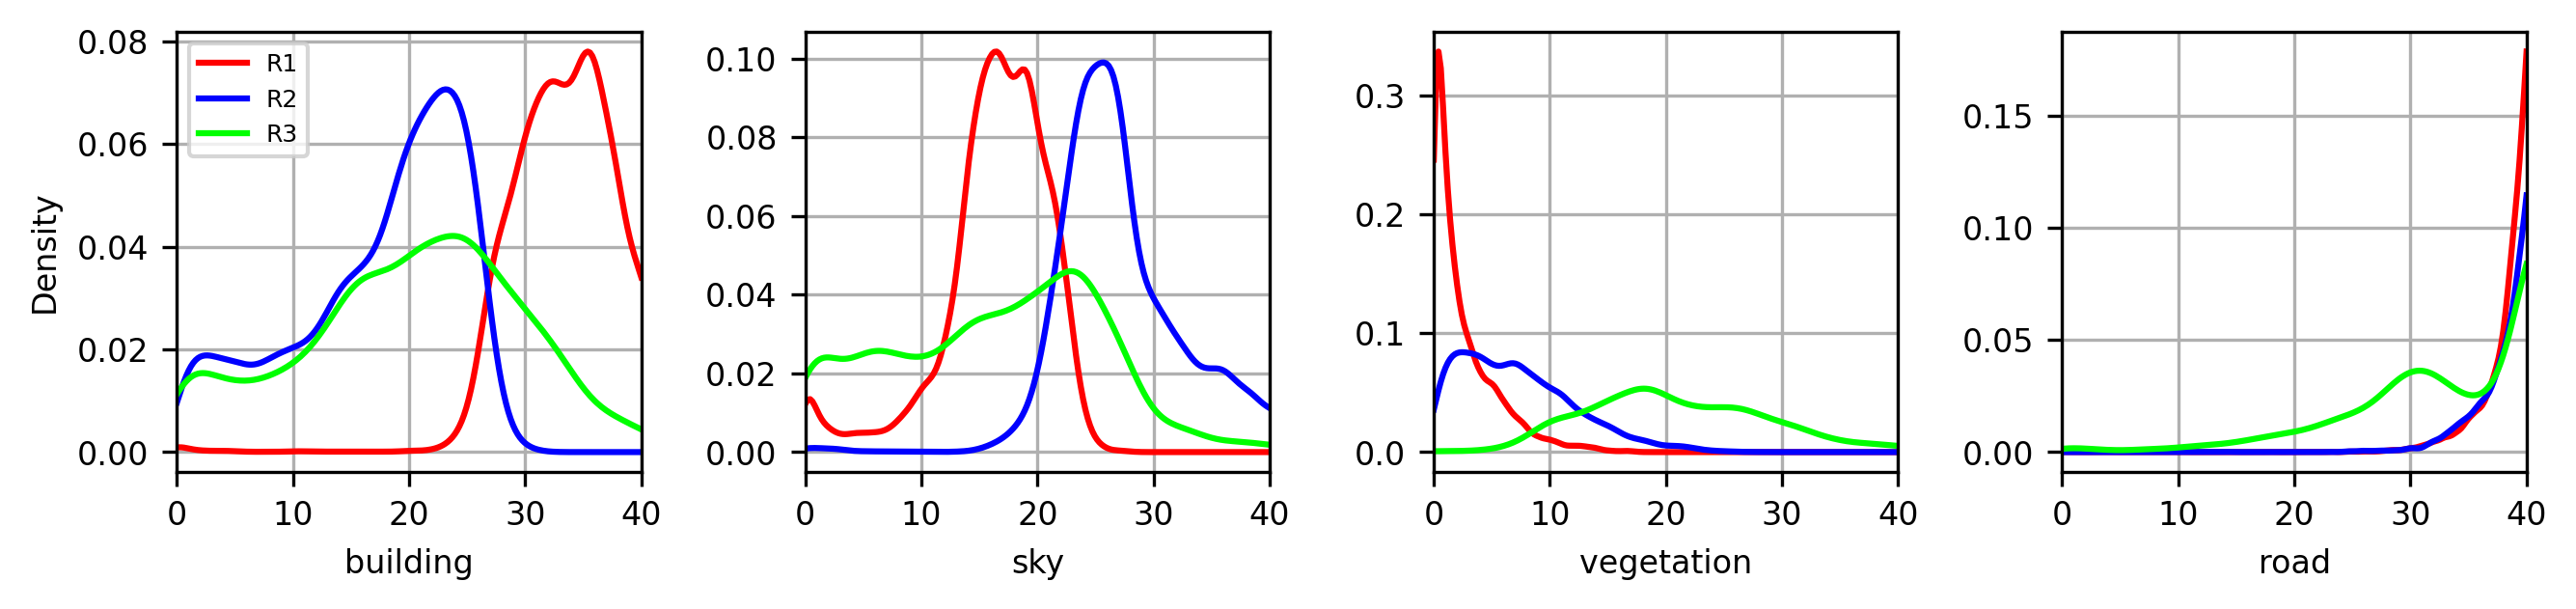

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, ks_2samp
from scipy.spatial.distance import jensenshannon

# ===================== 配置区：替换为你的5个CSV路径与标签 =====================
file_configs = [
    {
        "path": "Merge_data_all_街景语义分割作图/R1 regime.csv",
        "label": "R1",
        "color": "#FF0000"
    },
    {
        "path": "Merge_data_all_街景语义分割作图/R2 regime.csv",
        "label": "R2",
        "color": "#0000FF"
    },
    {
        "path": "Merge_data_all_街景语义分割作图/R3 regime.csv",
        "label": "R3",
        "color": "#00FF00"
    },
    # {
    #     "path": "CentralWestern district//segmentation_proportions_香港中西区街景.csv",
    #     "label": "Central & Western",
    #     "color": "#2ca02c"
    # },
    # {
    #     "path": "Southdistrict/SouthernDistrict segmentation_class_proportions.csv",
    #     "label": "Southern",
    #     "color": "#9467bd"
    # }
]
feature_list = ["building", "sky", "vegetation", "road"]
output_dir = "kde_distribution_plots"
os.makedirs(output_dir, exist_ok=True)
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ==========================================================================

# 1. 批量读取全部数据
dataset_list = []
for cfg in file_configs:
    df = pd.read_csv(cfg["path"], low_memory=False)
    feat_df = df[feature_list].select_dtypes(include=np.number).dropna()
    dataset_list.append({
        "label": cfg["label"],
        "color": cfg["color"],
        "data": feat_df
    })
    print(f"{cfg['label']} loaded, valid samples: {len(feat_df)}")

# 提取基准数据集 YTM
base_ds = dataset_list[0]
compare_ds_list = dataset_list[1:]

# 定义分布差异计算工具函数
def get_kde_pdf(samples, x_grid):
    kde = gaussian_kde(samples)
    return kde(x_grid)

def kl_divergence(p, q, eps=1e-10):
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q)) * (x_grid[1] - x_grid[0])

def integrated_sq_error(p, q):
    return np.sum((p - q) ** 2) * (x_grid[1] - x_grid[0])

# 统一x采样网格
x_grid = np.linspace(0, 40, 500)

# 存储所有度量结果
metric_records = []

# 2. 批量计算每个特征的分布差异指标
for feat_name in feature_list:
    base_vals = base_ds["data"][feat_name].values
    base_pdf = get_kde_pdf(base_vals, x_grid)

    for ds in compare_ds_list:
        comp_vals = ds["data"][feat_name].values
        comp_pdf = get_kde_pdf(comp_vals, x_grid)

        # KS距离
        ks_stat, _ = ks_2samp(base_vals, comp_vals)
        # JS散度 (0~1)
        js_div = jensenshannon(base_pdf, comp_pdf)
        # KL散度 D_KL(comp || base)
        kl_div = kl_divergence(comp_pdf, base_pdf)
        # 积分平方误差
        ise = integrated_sq_error(base_pdf, comp_pdf)

        metric_records.append({
            "Feature": feat_name,
            "Reference": base_ds["label"],
            "Target": ds["label"],
            "KS_Distance": round(ks_stat, 3),
            "JS_Divergence": round(js_div, 3),
            "KL_Divergence": round(kl_div, 3),
            "ISE": round(ise, 3)
        })

# 输出差异指标总表
metric_df = pd.DataFrame(metric_records)
print("\n===== KDE Distribution Difference Metrics (Baseline: Yau Tsim Mong) =====")
print(metric_df)
metric_df.to_csv(os.path.join(output_dir, "kde_dist_metrics.csv"), index=False)
print(f"\nMetrics table saved to {output_dir}/kde_dist_metrics.csv")

# 3. 原有一维KDE绘图逻辑不变
fig, axes = plt.subplots(1, len(feature_list), figsize=(9, 2.2), dpi=300)
for feat_idx, feat_name in enumerate(feature_list):
    ax = axes[feat_idx]
    for ds in dataset_list:
        vals = ds["data"][feat_name].values
        kde = gaussian_kde(vals)
        x_range = np.linspace(0, 40, 200)
        y_density = kde(x_range)
        ax.plot(x_range, y_density, c=ds["color"], lw=1.5, label=ds["label"])
    ax.set_xlabel(feat_name, fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid()
    if feat_idx == 0:
        ax.set_ylabel("Density", fontsize=8)
    ax.set_xlim(0, 40)
    
axes[0].legend(fontsize=6)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "all_features_kde_overlay.png"))
plt.show()